In [ ]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()


Saving Combines_Predictions_2025.xlsx to Combines_Predictions_2025.xlsx


,symbol,quarter,LR_FCF_Predicted,symbol.1,quarter.1,LSTM_FCF_Predicted,symbol.2,quarter.2,QSVM_FCF_Predicted,symbol.3,quarter.3,QNN_FCF_Predicted
0,AAPL,Q1 2025,241.054730,AAPL,Q1 2025,193.699321,AAPL,Q1 2025,236.243405,AAPL,Q1 2025,181.600362
1,AAPL,Q2 2025,241.054730,AAPL,Q2 2025,193.699321,AAPL,Q2 2025,236.243405,AAPL,Q2 2025,181.064060
2,AAPL,Q3 2025,241.054730,AAPL,Q3 2025,193.699321,AAPL,Q3 2025,236.243405,AAPL,Q3 2025,181.948839
3,AAPL,Q4 2025,241.054730,AAPL,Q4 2025,193.699321,AAPL,Q4 2025,236.243405,AAPL,Q4 2025,182.838169
4,AMZN,Q1 2025,179.507242,AMZN,Q1 2025,99.786828,AMZN,Q1 2025,173.607314,AMZN,Q1 2025,33.356606


In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1) LOAD YOUR COMBINED FILE
# =========================
# If you already have it as a DataFrame, skip this and set df = your_dataframe
#df = pd.read_excel("Combined_Predictions_2025.xlsx")
df = df.copy()  # if df already exists

# -------------------------
# Helper: clean columns
# -------------------------
df.columns = [str(c).strip() for c in df.columns]

# =========================
# 2) SPLIT EACH MODEL BLOCK
#    (because your file has repeated symbol/quarter columns)
# =========================
# Assumes columns are exactly like:
# ['symbol','quarter','LR_FCF_Predicted','symbol','quarter','LSTM_FCF_Predicted','symbol','quarter','QSVM_FCF_Predicted']
# Adjust indices if you also have QNN in the sheet.

lr = df.iloc[:, 0:3].copy()
lr.columns = ["symbol", "quarter", "fcf_pred"]
lr["model"] = "LR"

lstm = df.iloc[:, 3:6].copy()
lstm.columns = ["symbol", "quarter", "fcf_pred"]
lstm["model"] = "LSTM"

qsvm = df.iloc[:, 6:9].copy()
qsvm.columns = ["symbol", "quarter", "fcf_pred"]
qsvm["model"] = "QSVM"

qnn = df.iloc[:, 9:12].copy()
qnn.columns = ["symbol", "quarter", "fcf_pred"]
qnn["model"] = "QNN"

# Combine into long format: symbol | quarter | model | fcf_pred
pred_long = pd.concat([lr, lstm, qsvm, qnn], ignore_index=True)

# Make numeric + clean
pred_long["fcf_pred"] = pd.to_numeric(pred_long["fcf_pred"], errors="coerce")
pred_long = pred_long.dropna(subset=["symbol", "quarter", "fcf_pred"])

# =========================
# 3) ANNUALIZE: sum Q1–Q4 2025 per symbol×model
# =========================
annual_fcf = (
    pred_long
    .groupby(["symbol", "model"], as_index=False)["fcf_pred"]
    .sum()
    .rename(columns={"fcf_pred": "FCF_2025"})
)

# =========================
# 4) SCENARIO SIMULATION ASSUMPTIONS
# =========================
SCENARIOS = {
    "Optimistic": 1.10,
    "Neutral":    1.00,
    "Pessimistic":0.85
}

DISCOUNT_RATE = 0.08    # r
TERMINAL_GROWTH = 0.02  # g

if DISCOUNT_RATE <= TERMINAL_GROWTH:
    raise ValueError("Discount rate must be > terminal growth rate.")

# =========================
# 5) DCF VALUATION (Gordon Growth anchored on 2025 annual FCF)
#    Value = FCF_2025*(1+g)/(r-g)
# =========================
rows = []
for _, row in annual_fcf.iterrows():
    sym = row["symbol"]
    model = row["model"]
    base_fcf = float(row["FCF_2025"])

    for scen, mult in SCENARIOS.items():
        fcf_s = base_fcf * mult
        dcf_value = (fcf_s * (1 + TERMINAL_GROWTH)) / (DISCOUNT_RATE - TERMINAL_GROWTH)

        rows.append({
            "symbol": sym,
            "model": model,
            "scenario": scen,
            "FCF_2025": base_fcf,
            "FCF_2025_scenario": fcf_s,
            "discount_rate": DISCOUNT_RATE,
            "terminal_growth": TERMINAL_GROWTH,
            "DCF_Value": dcf_value
        })

dcf_results = pd.DataFrame(rows)

# =========================
# 6) TABLE: MODEL × SCENARIO (Mean DCF Value across firms)
# =========================
model_scenario_table = (
    dcf_results
    .groupby(["model", "scenario"])["DCF_Value"]
    .mean()
    .unstack("scenario")
    .reset_index()
)

# Optional: median table too (often better if outliers exist)
model_scenario_table_median = (
    dcf_results
    .groupby(["model", "scenario"])["DCF_Value"]
    .median()
    .unstack("scenario")
    .reset_index()
)

# =========================
# 7) SAVE OUTPUTS
# =========================
dcf_results.to_excel("DCF_Valuation_Symbol_Model_Scenario.xlsx", index=False)
model_scenario_table.to_excel("DCF_Model_x_Scenario_Mean.xlsx", index=False)
model_scenario_table_median.to_excel("DCF_Model_x_Scenario_Median.xlsx", index=False)

print("Saved:")
print(" - DCF_Valuation_Symbol_Model_Scenario.xlsx")
print(" - DCF_Model_x_Scenario_Mean.xlsx")
print(" - DCF_Model_x_Scenario_Median.xlsx")

# Preview
print("\nModel × Scenario (Mean DCF Value):")
print(model_scenario_table)

dcf_results.head()


Saved:
 - DCF_Valuation_Symbol_Model_Scenario.xlsx
 - DCF_Model_x_Scenario_Mean.xlsx
 - DCF_Model_x_Scenario_Median.xlsx

Model × Scenario (Mean DCF Value):
scenario model       Neutral    Optimistic   Pessimistic
0           LR  12130.880179  13343.968196  10311.248152
1         LSTM   8266.902908   9093.593199   7026.867472
2          QNN   3547.750680   3902.525748   3015.588078
3         QSVM  10552.299053  11607.528958   8969.454195


,symbol,model,scenario,FCF_2025,FCF_2025_scenario,discount_rate,terminal_growth,DCF_Value
0,AAPL,LR,Optimistic,964.218918,1060.640810,0.08,0.02,18030.893773
1,AAPL,LR,Neutral,964.218918,964.218918,0.08,0.02,16391.721612
2,AAPL,LR,Pessimistic,964.218918,819.586081,0.08,0.02,13932.963370
3,AAPL,LSTM,Optimistic,774.797284,852.277013,0.08,0.02,14488.709213
4,AAPL,LSTM,Neutral,774.797284,774.797284,0.08,0.02,13171.553830


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your DCF results
uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()

models = sorted(df["model"].unique())
preferred_scenarios = ["Optimistic", "Neutral", "Pessimistic"]
scenarios = [s for s in preferred_scenarios if s in df["scenario"].unique()]
if not scenarios:
    scenarios = sorted(df["scenario"].unique())

# -----------------------------
# 1) Heatmap: mean DCF (Model×Scenario)
# -----------------------------
pivot_mean = (
    df.pivot_table(index="model", columns="scenario", values="DCF_Value", aggfunc="mean")
      .reindex(models)[scenarios]
)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(pivot_mean.values, aspect="auto")
ax.set_xticks(np.arange(len(scenarios)))
ax.set_xticklabels(scenarios)
ax.set_yticks(np.arange(len(models)))
ax.set_yticklabels(models)
ax.set_title("Mean DCF Value by Model and Scenario")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean DCF Value")

# annotate cells
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        ax.text(j, i, f"{pivot_mean.iloc[i, j]:,.0f}", ha="center", va="center")

plt.tight_layout()
plt.savefig("/mnt/data/dcf_heatmap_mean.png", dpi=200)
plt.show()

# -----------------------------
# 2) Grouped Bar: mean ± std DCF (Model×Scenario)
# -----------------------------
group_stats = (
    df.groupby(["model", "scenario"])["DCF_Value"]
      .agg(["mean", "std"])
      .reset_index()
)

x = np.arange(len(models))
width = 0.25 if len(scenarios) >= 3 else 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for k, scen in enumerate(scenarios):
    sub = group_stats[group_stats["scenario"] == scen].set_index("model").reindex(models)
    ax.bar(
        x + (k - (len(scenarios)-1)/2)*width,
        sub["mean"].values,
        width,
        yerr=sub["std"].values,
        capsize=3,
        label=scen
    )

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("DCF Value (mean ± std)")
ax.set_title("DCF Valuation Summary by Model and Scenario")
ax.legend()

plt.tight_layout()
plt.savefig("/mnt/data/dcf_bar_mean_std.png", dpi=200)
plt.show()

# -----------------------------
# 3) Boxplots: distribution across firms (one plot per scenario)
# -----------------------------
for scen in scenarios:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    data = [
        df[(df["scenario"] == scen) & (df["model"] == m)]["DCF_Value"].dropna().values
        for m in models
    ]
    ax.boxplot(data, labels=models, showfliers=False)
    ax.set_title(f"DCF Value Distribution by Model ({scen} Scenario)")
    ax.set_ylabel("DCF Value")

    out = f"/mnt/data/dcf_boxplot_{scen.lower()}.png"
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()


KeyboardInterrupt: 

Saving DCF_Valuation_Symbol_Model_Scenario.xlsx to DCF_Valuation_Symbol_Model_Scenario (1).xlsx


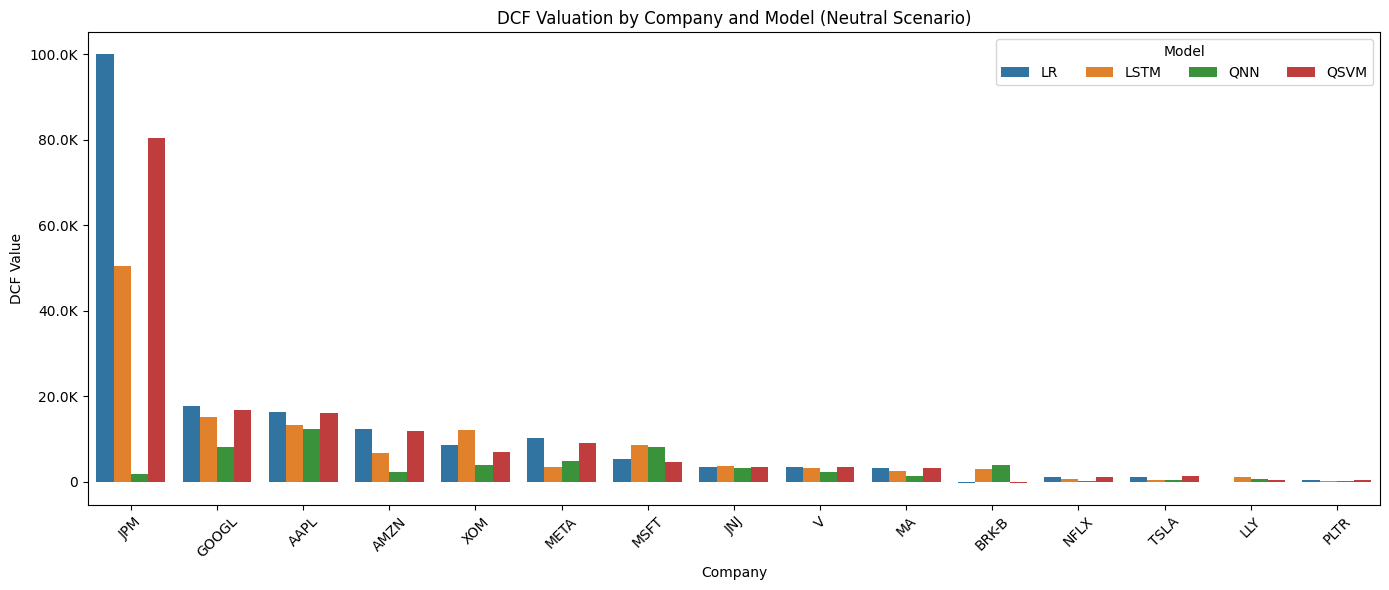

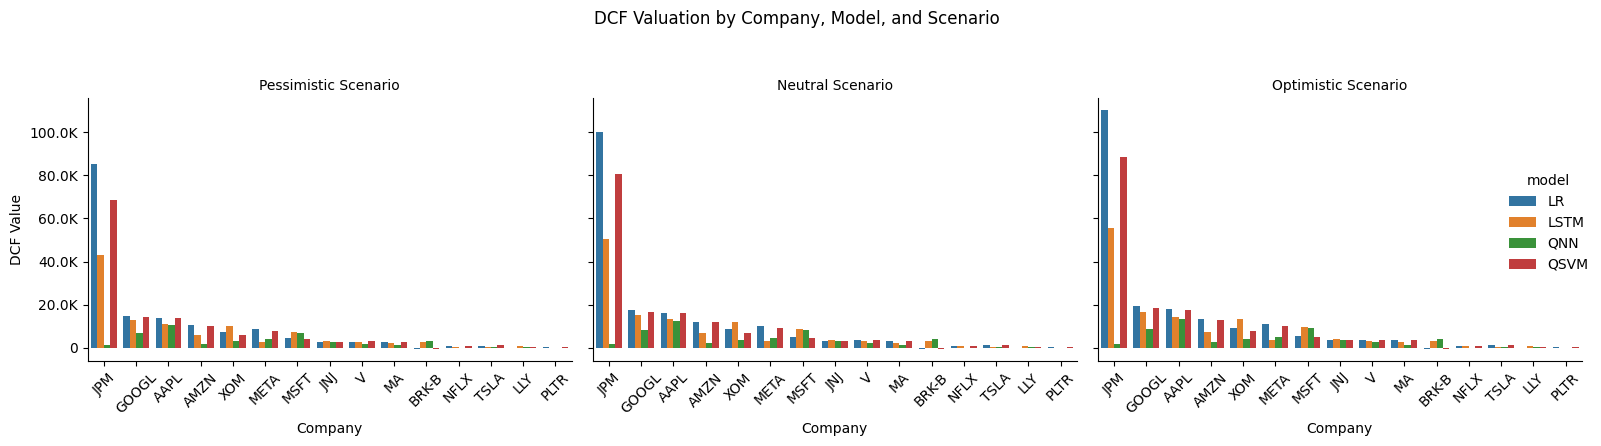

/tmp/ipython-input-1424658054.py:134: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


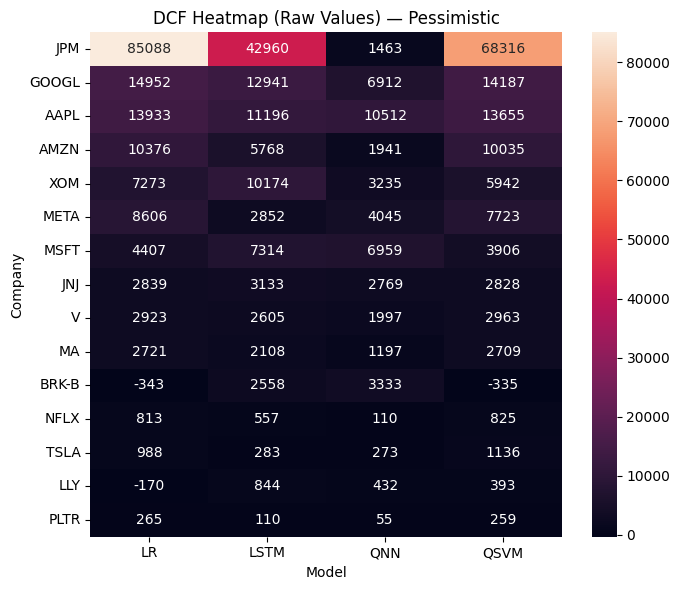

/tmp/ipython-input-1424658054.py:134: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


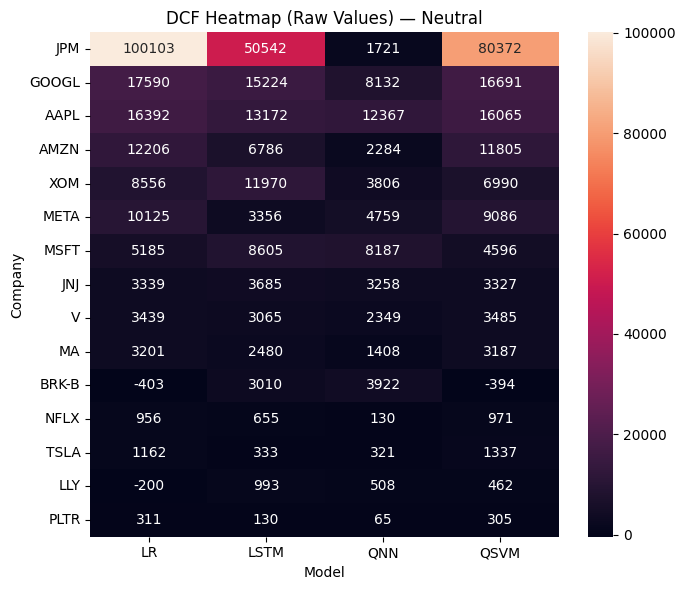

/tmp/ipython-input-1424658054.py:134: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


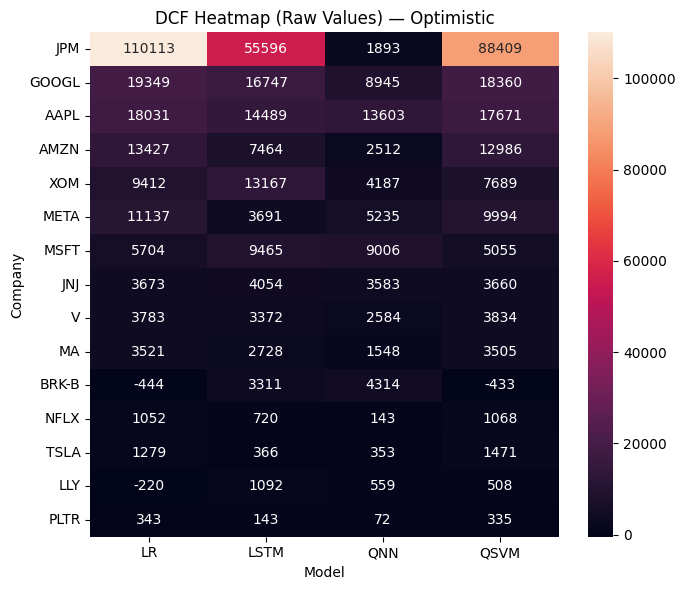

/tmp/ipython-input-1424658054.py:158: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


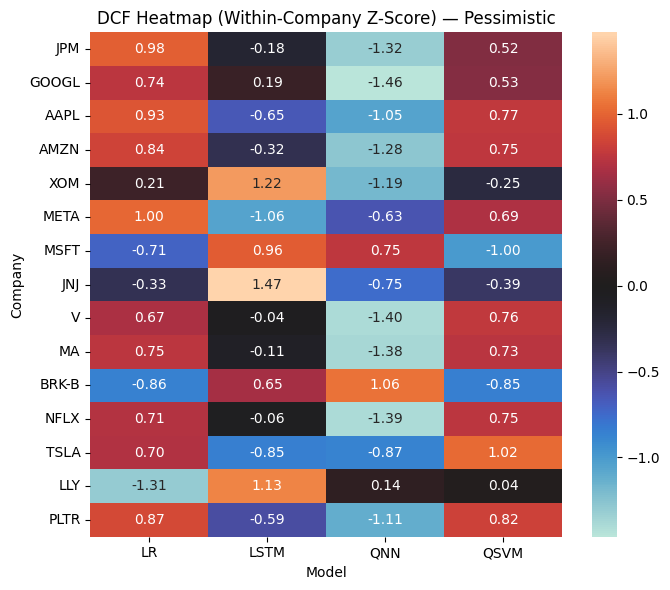

/tmp/ipython-input-1424658054.py:158: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


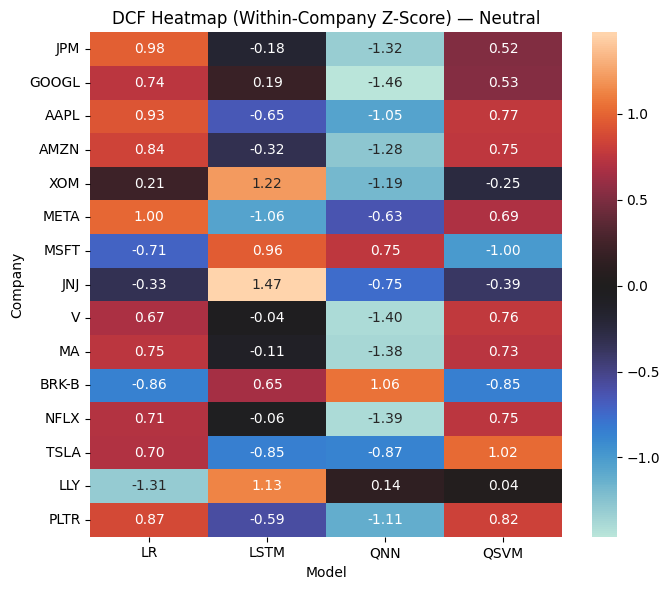

/tmp/ipython-input-1424658054.py:158: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")


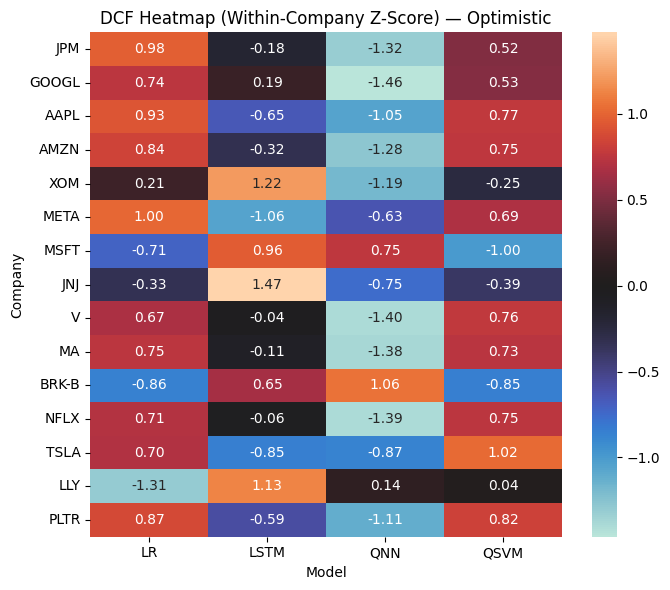

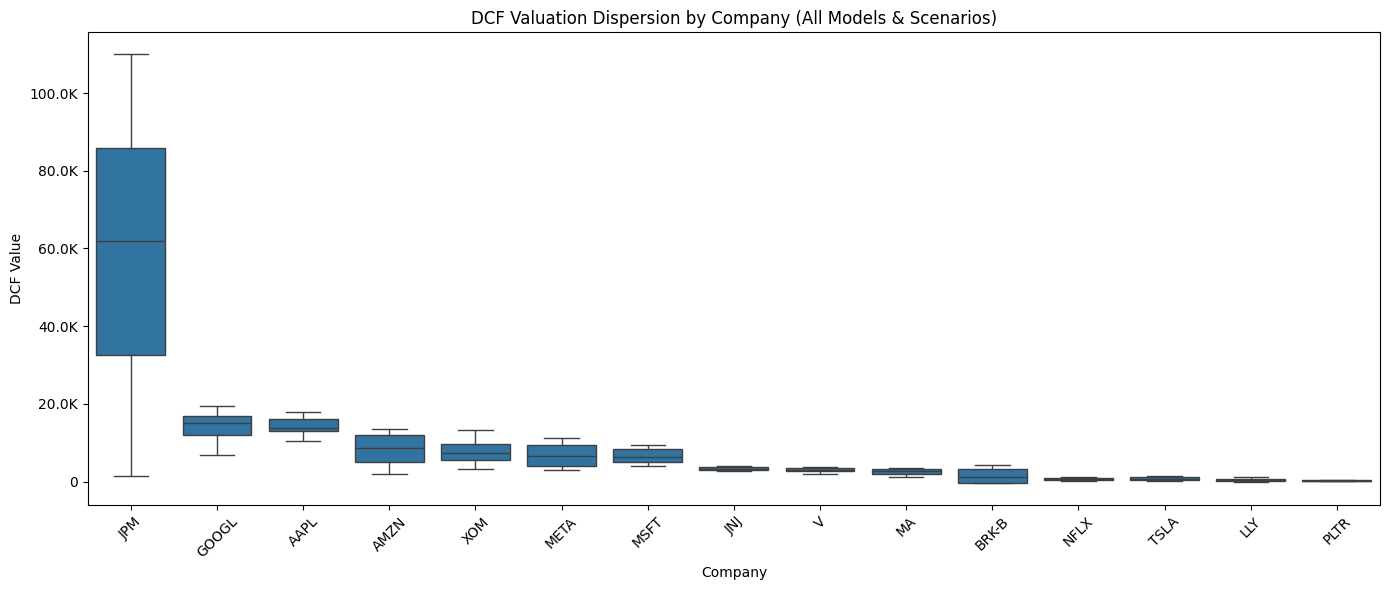

Saved figures:
 - DCF_groupedbar_neutral.png
 - DCF_groupedbar_by_scenario.png
 - DCF_heatmap_raw_<scenario>.png
 - DCF_heatmap_zscore_<scenario>.png
 - DCF_boxplot_dispersion_all.png


In [ ]:
# DCF valuation visuals (Grouped bars, Heatmaps, Boxplots)
# File: /mnt/data/DCF_Valuation_Symbol_Model_Scenario.xlsx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()

# ----------------------------
# 1) Load + basic cleanup
# ----------------------------


required = {"symbol", "model", "scenario", "DCF_Value"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()
df["model"] = df["model"].astype(str).str.strip()
df["scenario"] = df["scenario"].astype(str).str.strip()

# Optional: enforce a nice scenario order
scenario_order = ["Pessimistic", "Neutral", "Optimistic"]
df["scenario"] = pd.Categorical(df["scenario"], categories=scenario_order, ordered=True)

# Optional: order companies by Neutral scenario median valuation (keeps plots readable)
neutral_order = (
    df[df["scenario"] == "Neutral"]
    .groupby("symbol")["DCF_Value"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
df["symbol"] = pd.Categorical(df["symbol"], categories=neutral_order, ordered=True)

# Optional: control model order (edit to your preferred order)
model_order = ["LR", "LSTM", "QNN", "QSVM"]
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)

# ----------------------------
# 2) Helpers
# ----------------------------
def money_formatter(x, pos):
    # format large numbers: 12.3K / 4.5M / 1.2B
    absx = abs(x)
    if absx >= 1e9:
        return f"{x/1e9:.1f}B"
    if absx >= 1e6:
        return f"{x/1e6:.1f}M"
    if absx >= 1e3:
        return f"{x/1e3:.1f}K"
    return f"{x:.0f}"

def save_show(fig, filename, dpi=300):
    fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight")
    plt.show()

# ----------------------------
# 3) Figure A: Grouped bar chart (Neutral scenario) — best “main thesis figure”
# ----------------------------
neutral = df[df["scenario"] == "Neutral"].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=neutral,
    x="symbol",
    y="DCF_Value",
    hue="model",
    ax=ax,
    errorbar=None
)
ax.set_title("DCF Valuation by Company and Model (Neutral Scenario)")
ax.set_xlabel("Company")
ax.set_ylabel("DCF Value")
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Model", ncol=min(4, neutral["model"].nunique()), frameon=True)

save_show(fig, "DCF_groupedbar_neutral.png")

# ----------------------------
# 4) Figure B: Grouped bar charts by scenario (3 panels)
# ----------------------------
g = sns.catplot(
    data=df,
    kind="bar",
    x="symbol",
    y="DCF_Value",
    hue="model",
    col="scenario",
    col_order=scenario_order,
    errorbar=None,
    height=4.2,
    aspect=1.2,
    sharey=True
)
g.set_titles("{col_name} Scenario")
g.set_axis_labels("Company", "DCF Value")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
    ax.tick_params(axis="x", rotation=45)

g.fig.suptitle("DCF Valuation by Company, Model, and Scenario", y=1.05)
g.fig.tight_layout()
g.fig.savefig("DCF_groupedbar_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# 5) Figure C: Heatmap (raw DCF values) per scenario
#    Rows = companies, Columns = models, Cells = DCF_Value
# ----------------------------
for scen in scenario_order:
    pivot = (
        df[df["scenario"] == scen]
        .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")
        .reindex(index=neutral_order, columns=model_order)
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".0f",
        cbar=True
    )
    ax.set_title(f"DCF Heatmap (Raw Values) — {scen}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Company")
    save_show(fig, f"DCF_heatmap_raw_{scen.lower()}.png")

# ----------------------------
# 6) Figure D: Heatmap (normalized within each company) — best for pattern/bias across models
#    Normalization: z-score across models within each company for a given scenario
# ----------------------------
for scen in scenario_order:
    pivot = (
        df[df["scenario"] == scen]
        .pivot_table(index="symbol", columns="model", values="DCF_Value", aggfunc="mean")
        .reindex(index=neutral_order, columns=model_order)
    )

    # z-score per row (company) to highlight relative differences across models
    z = pivot.sub(pivot.mean(axis=1), axis=0).div(pivot.std(axis=1).replace(0, np.nan), axis=0)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        z,
        ax=ax,
        annot=True,
        fmt=".2f",
        center=0,
        cbar=True
    )
    ax.set_title(f"DCF Heatmap (Within-Company Z-Score) — {scen}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Company")
    save_show(fig, f"DCF_heatmap_zscore_{scen.lower()}.png")

# ----------------------------
# 7) Figure E: Boxplot — valuation dispersion per company (across all models + scenarios)
#    Great for “uncertainty / model risk” framing
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df,
    x="symbol",
    y="DCF_Value",
    ax=ax
)
ax.set_title("DCF Valuation Dispersion by Company (All Models & Scenarios)")
ax.set_xlabel("Company")
ax.set_ylabel("DCF Value")
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.tick_params(axis="x", rotation=45)

save_show(fig, "DCF_boxplot_dispersion_all.png")

print("Saved figures:")
print(" - DCF_groupedbar_neutral.png")
print(" - DCF_groupedbar_by_scenario.png")
print(" - DCF_heatmap_raw_<scenario>.png")
print(" - DCF_heatmap_zscore_<scenario>.png")
print(" - DCF_boxplot_dispersion_all.png")
